Adapted from https://github.com/marcdelabarrera/nndp/blob/main/docs/source/notebooks/cake_eating_problem

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from deep_macrofin import PDEModel
from deep_macrofin import Comparator, OptimizerType, LossReductionMethod, set_seeds
from tqdm import tqdm
from torch.func import jacrev, hessian, vmap

In [2]:
class PDEModelCustomSample(PDEModel):
    def __init__(self, name, config, latex_var_mapping={}):
        super().__init__(name, config, latex_var_mapping)
        self.sample = self.sample_custom

    def sample_custom(self, epoch):
        N = self.batch_size
        t = torch.zeros(N, device=self.device)
        s = torch.tensor(np.random.uniform(size=N), dtype=torch.float32, device=self.device)
        return torch.stack([t, s], dim=1)

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "./models/cake_eating"
T = 5
params = {
    "T": T, # number of periods, t=0,...,T
    "N_simul":  1,
}

In [ ]:
def compute_u(s, c):
    return torch.log(s * c)

def compute_value_function(SV: torch.Tensor, compute_pi, compute_u, T, N_simul):
    B = SV.shape[0]
    SV = torch.repeat_interleave(SV, repeats=N_simul, dim=0) # For each initial value, perform N_simul monte carlo samples
    V = torch.zeros((SV.shape[0], 1), device=SV.device) # (B*N_simul, 1)
    curr_state = SV
    for time_iter in range(T + 1):
        t = curr_state[...,0:1] # (B*N_simul, 1)
        s = curr_state[...,1:2] # (B*N_simul, 1)

        # compute policy and value function
        c = compute_pi(curr_state) # (B*N_simul, 1)
        V += compute_u(s, c)

        # update to next state
        t_next = t + 1 # (B*N_simul, 1)
        s_next = s * (1 - c)# (B*N_simul, 1)
        curr_state = torch.cat([t_next, s_next], dim=1)
    V = V.reshape(B, N_simul, 1).mean(dim=1) # average across all monte carlo samples to find the expectation
    return -torch.mean(V) # the final loss is the average across all batches, we want to maximize the value function, so negative loss

def get_model(model_path: str, params: dict, model_size: list[int]):
    set_seeds(0)
    model = PDEModelCustomSample("cake_eating", config={"batch_size": 250, "num_epochs": 200, "optimizer_type": OptimizerType.Adam, "lr": 1e-3, "loss_log_interval": 1})
    model.set_state(["t", "s"], 
        {"t": [0, params["T"] + 1], "s": [0, 1]} # override sampling
    )
    model.add_agent("pi", config={"hidden_units": model_size, "derivative_order": 0, "sigmoid": True})
    model.add_params(params)
    model.register_functions([
        compute_u, compute_value_function
    ])
    model.add_equations([
        "V=compute_value_function(SV, compute_pi, compute_u, T, N_simul)"
    ])
    model.add_hjb_equation("V", loss_reduction=LossReductionMethod.NONE)
    if not os.path.exists(f"{model_path}/model.pt"):
        model.train_model(model_path, "model.pt", True)
    model.load_model(torch.load(f"{model_path}/model_best.pt", weights_only=False))
    return model

In [7]:
model = get_model(model_path, params, [100]*4)

====================================Training====================================


Min loss: 16.8130: 100%|██████████| 200/200 [00:04<00:00, 45.87it/s]

training finished, total time :: 4.371792316436768
Best model saved to ./models/cake_eating/model_best.pt if valid
Model saved to ./models/cake_eating/model.pt
Model loaded


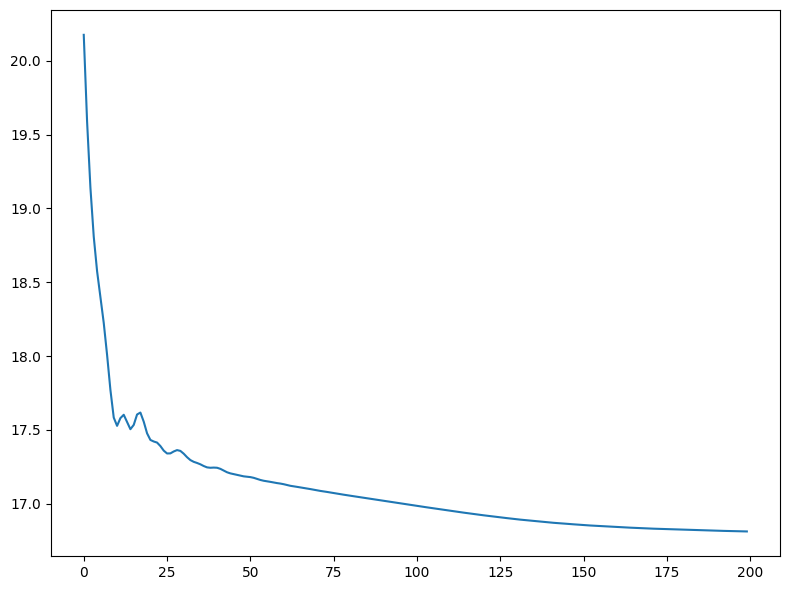

In [8]:
loss_dict = pd.read_csv(f"{model_path}/model_loss.csv")
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(loss_dict["epoch"], loss_dict["total_loss"])
plt.tight_layout()
plt.show()

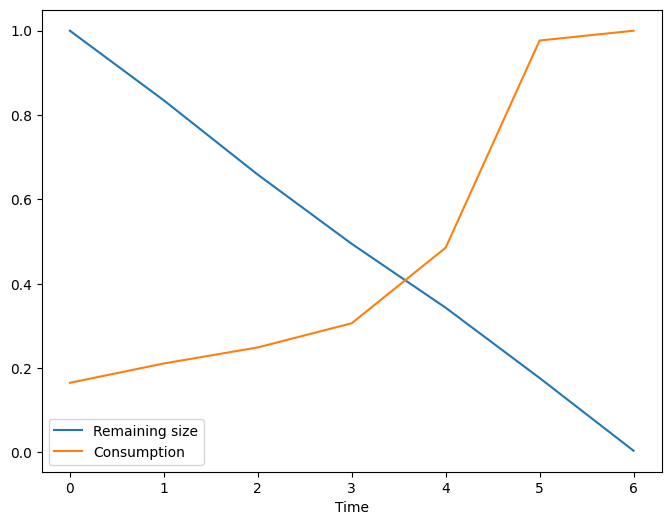

In [11]:
t_list = []
s_list = []
policy_list = []
for t in range(T+1):
    if t == 0:
        curr_s = 1
    else:
        curr_s = curr_s * (1 - c)
    SV = torch.tensor([[t, curr_s]], device=model.device, dtype=torch.float32)
    c = model.agents["pi"](SV).item()
    t_list.append(t)
    s_list.append(curr_s)
    policy_list.append(c)
t_list.append(T+1)
s_list.append(curr_s * (1 - c))
policy_list.append(1)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(t_list, s_list, label="Remaining size")
ax.plot(t_list, policy_list, label="Consumption")
ax.legend()
ax.set_xlabel("Time")
plt.show()

In [14]:
res_df = pd.DataFrame({"t": t_list, "s": s_list, "c": policy_list})
res_df

,t,s,c
0,0,1.000000,0.165138
1,1,0.834862,0.210981
2,2,0.658721,0.249060
3,3,0.494660,0.306321
4,4,0.343135,0.485553
5,5,0.176525,0.976804
6,6,0.004095,1.000000
